## **Matrix Transformations**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image 
import scipy
from skimage import data
from numpy import *

In [2]:
# Function to create square of side x
def plot_points(matrix, ls=':', lw=6):
    x_points, y_points = matrix
    size = len(x_points)
    colors = ['red', 'green', 'blue', 'black'] if not None else colors
    for i in range(size):
        plt.plot(x_points[i], y_points[i], color=colors[i], marker='*')
        plt.plot([x_points[i], x_points[(i+1) % size]], 
             [y_points[i], y_points[(i+1) % size]], 
             linestyle=ls, linewidth=lw)

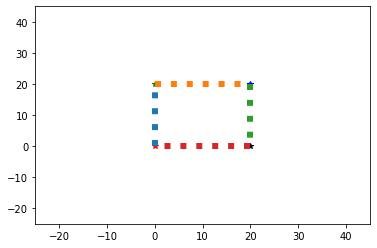

In [3]:
# Using above function to create a square of side 20
x_points = np.array([0, 0, 20, 20])
y_points = np.array([0, 20, 20, 0])
matrix = np.array([x_points, y_points])
colors = ['red', 'green', 'blue', 'black']
size = len(x_points)
plot_points(matrix)
plt.ylim([-25,45])
plt.xlim([-25,45])
#plt.axes().set_aspect('equal')
plt.show()

In [4]:
# Points generator
#def get_grid(x, y, homogenous=False):
#    coords = np.indices((x, y)).reshape(2, -1) 
#    return np.vstack((coords, np.ones(coords.shape[1]))) if homogenous else coords

x = np.array([0, 0, 20, 20])
y = np.array([0, 20, 20, 0])
matrix = np.array([x, y])
matrix
matrix_grid=np.vstack([matrix,[1, 1, 1, 1]])
print(matrix_grid)
#get_grid(x,y,homogenous=False)

[[ 0  0 20 20]
 [ 0 20 20  0]
 [ 1  1  1  1]]


In [5]:
# Define Transformations
def get_rotation(angle):
    angle = np.radians(angle)
    return np.array([

[np.cos(angle), -np.sin(angle), 0],
[np.sin(angle), np.cos(angle), 0],
[0, 0, 1]
])

get_rotation(90)

array([[ 6.123234e-17, -1.000000e+00,  0.000000e+00],
       [ 1.000000e+00,  6.123234e-17,  0.000000e+00],
       [ 0.000000e+00,  0.000000e+00,  1.000000e+00]])

In [6]:
def get_translation(tx, ty):
    return np.array([
                        [1, 0, tx],  
                        [0, 1, ty], 
                        [0, 0, 1]
                    ])


In [7]:
def get_scale(s):
    return np.array([
        [s, 0, 0],
        [0, s, 0],
        [0, 0, 1]
])

R1 = get_rotation(45)
T1 = get_translation(20, 20)
S1 = get_scale(2)

In [8]:
print(R1)

[[ 0.70710678 -0.70710678  0.        ]
 [ 0.70710678  0.70710678  0.        ]
 [ 0.          0.          1.        ]]


In [9]:
# Apply transformation x' = Ax
coords_rot = R1 @ matrix_grid    #Rotation Transformation
print(coords_rot)


[[ 0.00000000e+00 -1.41421356e+01  1.77635684e-15  1.41421356e+01]
 [ 0.00000000e+00  1.41421356e+01  2.82842712e+01  1.41421356e+01]
 [ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00]]


In [10]:
matrix_grid

array([[ 0,  0, 20, 20],
       [ 0, 20, 20,  0],
       [ 1,  1,  1,  1]])

In [11]:
coords_trans = T1 @ matrix_grid  #Translation Transformation
coords_trans

array([[20, 20, 40, 40],
       [20, 40, 40, 20],
       [ 1,  1,  1,  1]])

In [12]:
coords_scale = S1 @ matrix_grid  #Scale Transformation
coords_scale

array([[ 0,  0, 40, 40],
       [ 0, 40, 40,  0],
       [ 1,  1,  1,  1]])

In [13]:
coords_composite1 = R1 @ T1 @ matrix_grid
coords_composite1

array([[ 1.77635684e-15, -1.41421356e+01,  3.55271368e-15,
         1.41421356e+01],
       [ 2.82842712e+01,  4.24264069e+01,  5.65685425e+01,
         4.24264069e+01],
       [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00]])

In [14]:
coords_composite2 = T1 @ R1 @ matrix_grid
coords_composite2

array([[20.        ,  5.85786438, 20.        , 34.14213562],
       [20.        , 34.14213562, 48.28427125, 34.14213562],
       [ 1.        ,  1.        ,  1.        ,  1.        ]])

In [15]:
coords_trans = T1 @ matrix_grid  #Translation Transformation
coords_scale = S1 @ matrix_grid  #Scale Transformation
coords_composite1 = R1 @ T1 @ matrix_grid
coords_composite2 = T1 @ R1 @ matrix_grid

## Rotation 

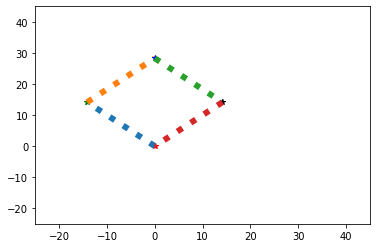

In [16]:
coords_rot_corrected = np.delete(coords_rot, 2, 0)
plot_points(coords_rot_corrected)
plt.ylim([-25,45])
plt.xlim([-25,45])
#plt.axes().set_aspect('equal')
plt.show()

## Translation

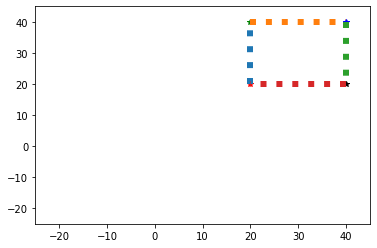

In [17]:
coords_trans_corrected = np.delete(coords_trans, 2, 0)
plot_points(coords_trans_corrected)
plt.ylim([-25,45])
plt.xlim([-25,45])
#plt.axes().set_aspect('equal')
plt.show()

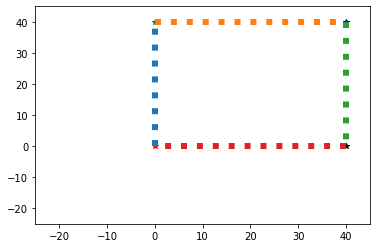

In [18]:
coords_rot_corrected = np.delete(coords_scale, 2, 0)
plot_points(coords_rot_corrected)
plt.ylim([-25,45])
plt.xlim([-25,45])
#plt.axes().set_aspect('equal')
plt.show()

## Matrix operations




### Determinant

In [22]:
# matrix determinant
from numpy import array
from numpy.linalg import det,inv
# define matrix
A = array([
[8, 2, 1],
[4, 7, 6],
[5, 8, 4]])
print(A)

[[8 2 1]
 [4 7 6]
 [5 8 4]]


In [23]:
# calculate determinant
B = det(A)
print(B)

-135.00000000000003


In [24]:
# det(inv(A))=1/det(A)
print(det(inv(A)))
print(1/det(A))

-0.007407407407407413
-0.007407407407407406


### Rank

In [ ]:
# vector rank
from numpy import array
from numpy.linalg import matrix_rank
# rank
v1 = array([1,2,3])
print(v1)
vr1 = matrix_rank(v1)
print('Rank = ',vr1)

In [ ]:
# zero rank vector
v2 = array([0,0,0,0,0])
print(v2)
vr2 = matrix_rank(v2)
print('Rank = ',vr2)

In [ ]:
# matrix rank
from numpy import array
from numpy.linalg import matrix_rank
# Matrix rank 0
M0 = array([
[0,0],
[0,0]])
print(M0)
mr0 = matrix_rank(M0)
print('Rank = ',mr0)
# Matrix rank 1 
M1 = array([
[1,2],
[1,2]])
print(M1)
mr1 = matrix_rank(M1)
print('Rank = ',mr1)

In [ ]:
# Matrix rank 2
M2 = array([
[1,2],
[3,4]])
print(M2)
mr2 = matrix_rank(M2)
print('Rank = ',mr2)

### Matrix Inverse

In [ ]:
from numpy.linalg import inv
import numpy as np

A = np.array([
[1, 2, 3],
[1, 5, 4],
[7, 1, 9]])

B = np.array([1, -1 , 1])
x=inv(A).dot(B.T)
#
x

In [ ]:
print(inv(A))

In [ ]:
print(A.dot(inv(A)))  

## System of linear equations

Matrix Inverse

*Solve* Ax=b using 'solve'

In [ ]:
from numpy.linalg import solve
x = solve(A,B.T)
print(x)

Solve the $$\begin{pmatrix}
1&2\\
3&4
\end{pmatrix} \begin{pmatrix}
x\\
y
\end{pmatrix} =\begin{pmatrix}
-1\\
1
\end{pmatrix}$$

$x=\frac{4\cdot -1-2\cdot 1}{1\cdot 4-2\cdot 3}=\frac{-6}{-2}=3$

$y=\frac{1\cdot 1-3\cdot -1}{1\cdot 4-2\cdot 3}=\frac{4}{-2}=-2$


In [ ]:
from numpy import array
A=array([[1,2],[3,4]])
b=array([[-1,1]])
print(A)
print(b)

In [ ]:
from numpy.linalg import inv
x=inv(A).dot(b.T)
print(x)

## Eigen Values and Vectors


In [ ]:
import numpy as np
import scipy.linalg as la
T= np.array(((2,1),(1,1)))
eigvals, eigvecs=la.eig(T)
eigvals

In [ ]:
eigvals

## Eigen basis and Transformations/ Diagonalization

#####  Matrix diagonalization is the process of performing a similarity transformation on a matrix in order to recover a similar matrix that is diagonal (i.e., all its non-diagonal entries are zero).

##### Once a matrix is diagonalized it becomes very easy to raise it to integer powers.

##### Not all matrices are diagonalizable. The diagonalizable matrices are those that have no defective eigenvalues (i.e., eigenvalues whose geometric multiplicity is less than their algebraic multiplicity).


## Similarity transformations
- Remember that two square matrices $A$ and $B$ are said to be similar if there exists an invertible 
-  $ k \times k $ Matrix   $ P $ such that $ B = P^{-1}AP $
- If two matrices are similar, then they have the same rank, trace, determinant and eigenvalues.
- Not only two similar matrices have the same eigenvalues, but their eigenvalues have the same algebraic and geometric multiplicities.


## Diagonalizable matrix
- We can now provide a definition of diagonalizable matrix.

- Definition Let A be a $ k \times k $ matrix. We say that A is diagonalizable if and only if it is similar to a diagonal matrix.

- In other words, when A is diagonalizable, then there exists an invertible matrix $P$ such that
  $ D = P^{-1}AP $
  
  
- Consider the matrix 
$ A = \bigl(\begin{smallmatrix}
 -1 & 2 \\ 
 0 &  3
\end{smallmatrix}\bigr)$

In [ ]:
A = np.array([[-1,2],[0,3]])
print(A)

- Can we find P such that $ D = P^{-1}AP $ and $D$ is diagonal Matrix
- $P$ is a matrix of Eigen vectors of $A$ and $D$ is a matrix of eigen values of $A$

In [ ]:
# Eigen Values of A 
eigvals, eigvecs=la.eig(A)
eigvals

In [ ]:
# Lets Create D out of eigenavlues of A
D = np.array(((1,0),(0,1)))*eigvals
D

In [ ]:

P=eigvecs

P

In [ ]:
inv_P=np.linalg.inv(P)
inv_P

Now consider $ P^{-1}AP$

In [ ]:
inv_P@A@P

In [ ]:
D==inv_P@A@P  # Shows that D = P^{-1}AP

### Most Important Application
- We can find power of any given matrix
- $ D = P^{-1}AP $  hence 
- $ A = PDP^{-1}$
- $ A^{n}$ = $\underbrace{P^{-1}DP\times P^{-1}DP \times...\times P^{-1}DP}_{n-times} $
- $ A^{n} = P^{-1}D^{n}P$

### In the above problem 
$ A^{2}= P^{-1}D^2P $


In [ ]:
D_sq=D@D
D_sq

In [ ]:
A_sq=A@A
A_sq

In [ ]:
inv_P

In [ ]:
P

In [ ]:
final=inv_P@D_sq@P
final

In [ ]:
A_sq == final